In [ ]:
# Author : YOU

In [ ]:
# IMPORT SECTION
# We have to start a import section in order to make it easier to MAINTAIN
import datetime # for the dates and time
import pandas as pd
import matplotlib.pyplot as plt # for the plots
import numpy as np
import pandas_datareader.data as web # in industry we use GCP (Ggle Cloud Plt)


In [ ]:
stock_ticker = "GFTC" # String : to reprents labels or name s
market_price = 150.25 # FLOAT
share_traded = 1000 # INTEGER
is_volatile = True # BOOLEAM

print(f"Asset: {stock_ticker}")
print(f"Market Price: {market_price}")
print(f"Share Traded: {share_traded}")
print(f"Is Volatile: {is_volatile}")
print(f"Asset {stock_ticker} | Prince : {share_traded} | Type : {is_volatile}")

Asset: GFTC
Market Price: 150.25
Share Traded: 1000
Is Volatile: True
Asset GFTC | Prince : 1000 | Type : True


In [ ]:
# Create a dictionary in Finance hardcoded values
data = { 'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10'],
        'Sector': ['Tech', 'Fin', 'Tech', 'Energy',
                   'Fin', 'Tech', 'Energy', 'Tech', 'Retail', 'Retail'],
         'Returns': [0.05, 0.02, -0.01, 0.08, np.nan, 0.04, 0.15, -0.02, 0.01, 5.0],
         'Volatility': [0.12, 0.08, 0.15, 0.20, 0.10, 0.11, 0.25, 0.13, 0.09, 0.10],
         'Description': ['High growth tech', 'Stable financial', 'Volatile software', 'Oil production', 'Unknown bank', 'AI startup', 'Solar energy', 'E-commerce', 'Store A', 'Store B'] }


In [ ]:
df_fin = pd.DataFrame(data)
display(df_fin.head())

,Asset_ID,Sector,Returns,Volatility,Description
0,A1,Tech,0.05,0.12,High growth tech
1,A2,Fin,0.02,0.08,Stable financial
2,A3,Tech,-0.01,0.15,Volatile software
3,A4,Energy,0.08,0.20,Oil production
4,A5,Fin,NaN,0.10,Unknown bank


In [ ]:
# MISSING VALUES
# What do you do wehn you have missing valuues ?
# THE RISK OF MISSING VALUES IS TO HAVE BIAS RESULTS
# MAR/MCAR/MNAR
# MCAR: Missing Cpltely at RANDOM
# MAR: Missing related to obs variables
# MNAR: Missing RELATED to the value itself

In [ ]:
df_fin['Returns_Imp'] = df_fin['Returns'].fillna(df_fin['Returns'].mean())
display(df_fin.head())

,Asset_ID,Sector,Returns,Volatility,Description,Returns_Imp
0,A1,Tech,0.05,0.12,High growth tech,0.050000
1,A2,Fin,0.02,0.08,Stable financial,0.020000
2,A3,Tech,-0.01,0.15,Volatile software,-0.010000
3,A4,Energy,0.08,0.20,Oil production,0.080000
4,A5,Fin,NaN,0.10,Unknown bank,0.591111


In [ ]:
print(f"Gaps filed with the means is not prefect but good. Total NaNs now :{df_fin['Returns_Imp'].isna().sum()}")

Gaps filed with the means is not prefect but good. Total NaNs now :0


In [ ]:
# 4. Outliers & Winsorisation
# In finance we tend to often see 'FAT TAILS'. Single error can RUIN A MODEL.
# WINSORISATION CAPS extreme values at specific percentiles rather than deleting them.
from scipy.stats.mstats import winsorize
df_fin['Returns_Clean'] = winsorize(df_fin['Returns'], limits=[0.05, 0.05])

display(df_fin.head())


,Asset_ID,Sector,Returns,Volatility,Description,Returns_Imp,Returns_Clean
0,A1,Tech,0.05,0.12,High growth tech,0.050000,0.05
1,A2,Fin,0.02,0.08,Stable financial,0.020000,0.02
2,A3,Tech,-0.01,0.15,Volatile software,-0.010000,-0.01
3,A4,Energy,0.08,0.20,Oil production,0.080000,0.08
4,A5,Fin,NaN,0.10,Unknown bank,0.591111,NaN


Text(0.5, 1.0, 'Risk vs Return')

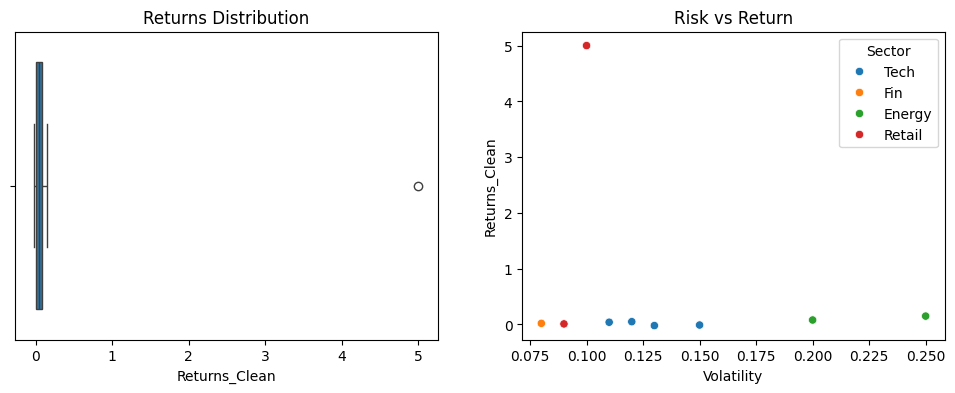

In [ ]:
# DATA VIZ (visualization)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)

# We forget to import sns thus
import seaborn as sns
sns.boxplot(x=df_fin['Returns_Clean']).set_title("Returns Distribution")

plt.subplot(1,2,2)
sns.scatterplot(data = df_fin, x= 'Volatility', y = 'Returns_Clean', hue = 'Sector').set_title('Risk vs Return')


In [ ]:
# The cool Econometrics part
# What is the PACKAGE used for the STATISFICAL MODEL ?

In [ ]:
import statsmodels.api as sm

In [ ]:
X = sm.add_constant(df_fin['Volatility'])

y = df_fin['Returns_Clean']

model = sm.OLS(y,X)

results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Returns_Clean   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Mon, 15 Jun 2026   Prob (F-statistic):                nan
Time:                        14:19:38   Log-Likelihood:                    nan
No. Observations:                  10   AIC:                               nan
Df Residuals:                       8   BIC:                               nan
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const             nan        nan        nan        n

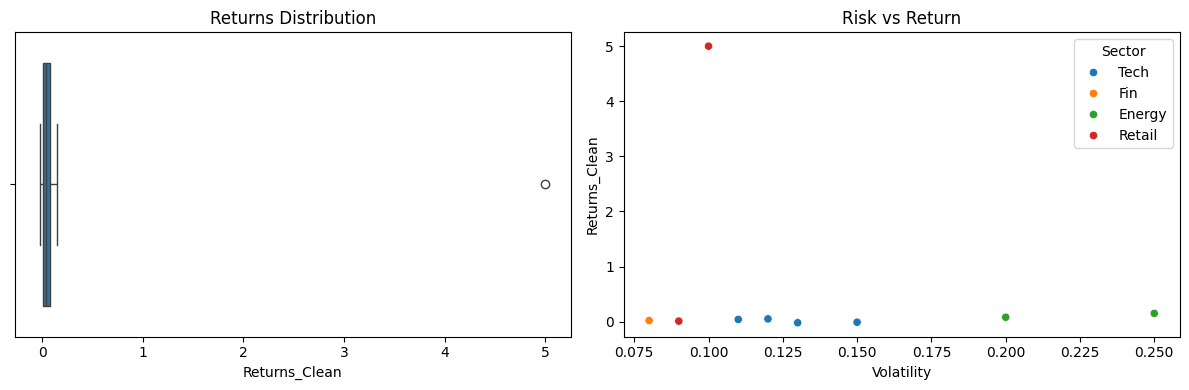

                            OLS Regression Results                            
Dep. Variable:          Returns_Clean   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                 -0.086
Method:                 Least Squares   F-statistic:                    0.3685
Date:                Mon, 15 Jun 2026   Prob (F-statistic):              0.563
Time:                        14:19:38   Log-Likelihood:                -16.539
No. Observations:                   9   AIC:                             37.08
Df Residuals:                       7   BIC:                             37.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4991      1.602      0.936      0.3

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# ==========================================
# 1. BULLETPROOF DATA CLEANING
# Clean the data to fix BOTH the plots and OLS!
# ==========================================
# Create a copy to avoid modifying the original dataframe accidentally
df_clean = df_fin.copy()

# Replace infinite values with NaN, then drop any rows containing NaN
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna(subset=['Returns_Clean', 'Volatility'])

# ==========================================
# 2. DATA VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 4))

# Left plot: Boxplot for Returns
plt.subplot(1, 2, 1)
sns.boxplot(x=df_clean['Returns_Clean']).set_title("Returns Distribution")

# Right plot: Scatterplot for Risk vs Return
plt.subplot(1, 2, 2)
# Added 'palette' just in case you want nice distinct colors for sectors
sns.scatterplot(data=df_clean, x='Volatility', y='Returns_Clean', hue='Sector').set_title('Risk vs Return')

plt.tight_layout() # This prevents the two plots from overlapping
plt.show()

# ==========================================
# 3. OLS REGRESSION
# ==========================================
# Using the completely clean dataset
X = sm.add_constant(df_clean['Volatility'])
y = df_clean['Returns_Clean']

# Fit the model
model = sm.OLS(y, X)
results = model.fit()

# Print the summary
print(results.summary())

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(df_fin[['Returns_Clean', 'Volatility']])
df_fin['Risk_Group'] = kmeans.labels_
print("Assets assigned to risk clusters.")

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
#But we need more to product
from sklearn.tree import DecisionTreeClassifier
from sklearn_metrics import classification_report # to ease the human reading
df_fin ['Target'] = (df_fin['Sector'] == 'Tech').astype (int)
X_clf = df_fin['Returs_Clean']

1.Using SQLite (In-Memory)
We can use the bulit-in squlite3 module to create a temporary database from our existing DataFrame.

In [ ]:
#Since it is more than just "simple data analytics"

# we will need to install the SQL PACKAGE
!pip install pandasql
# to install IT you need the EXCLAMATION POINT AND the PIP

In [ ]:
import sqlite3

In [ ]:
conn = sqlite3.connect(':memory:')
#this cerate an in-memory SQLite DB (database) so u use the vm of geogle

In [ ]:
df_fin.to_sql('finance_table',conn, index=False, if_exists='replace')
#then write the existing df_fin to the SQL database

10

In [ ]:
# WHAT ARE THE 3 WORDS used in SQL?
query="SELECT Sector ,AVG(Volatility) as Avg_Vol from finance_table Group BY Sector"
sql_results = pd.read_sql_query(query, conn)
display(sql_results)

,Sector,Avg_Vol
0,Energy,0.2250
1,Fin,0.0900
2,Retail,0.0950
3,Tech,0.1275


In [ ]:
#what if i want only sql and no more pandas?
#i can use a lambda fuction
from pandasql import sqldf

In [ ]:
pysqldf = lambda q: sqldf(q, globals())

In [ ]:
query_ps = """
SELECT Asset_ID, Sector, Returns_Clean
FROM df_fin
WHERE Sector = 'Tech'
"""
print(pysqldf(query_ps))

  Asset_ID Sector  Returns_Clean
0       A1   Tech           0.05
1       A3   Tech          -0.01
2       A6   Tech           0.04
3       A8   Tech          -0.02


In [99]:
asset_metadata = pd.DataFrame({ 'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5'],
                               'Full_Name': ['Apple Inc', 'JP Morgan', 'Microsoft',
                                             'Exxon Mobil', 'Goldman Sachs'],
                                'Country': ['USA', 'USA', 'USA', 'USA', 'USA'] })


In [100]:
# the advantage of SQL IS THE POWER of JOINING TABLES
# THE MOST used one is inner  join
# we will do a API CALL FOR THE FRED
fred_df_sql = sql = fred_data.reset_index()

NameError: name 'fred_data' is not defined

In [ ]:
query_fred= """
SELECT DATE,GDP
FROM fred_df_sql